# Task 3: Car Price Prediction with Machine Learning
### Predict Used Car Prices Using Regression Models
**Dataset:** [Car Price Prediction (Used Cars) – Kaggle](https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars)

---

## Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# XGBoost
from xgboost import XGBRegressor

print('Libraries imported!')
print(f'TensorFlow: {tf.__version__}')

Libraries imported!
TensorFlow: 2.19.0


## Step 2: Load Dataset

In [2]:
# ── Upload from Colab ──
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('car data.csv')

# ── Synthetic Representative Dataset ──
np.random.seed(42)
n = 500

brands = ['Maruti','Honda','Toyota','Hyundai','Ford','BMW','Audi','Volkswagen']
fuel_types = ['Petrol','Diesel','CNG']
seller_types = ['Dealer','Individual']
transmissions = ['Manual','Automatic']

brand    = np.random.choice(brands, n)
year     = np.random.randint(2005, 2021, n)
km_driven = np.random.randint(5000, 200000, n)
fuel     = np.random.choice(fuel_types, n)
seller   = np.random.choice(seller_types, n)
trans    = np.random.choice(transmissions, n)
owner    = np.random.choice([1,2,3,4], n, p=[0.5,0.3,0.15,0.05])
engine   = np.random.randint(800, 4000, n)
max_power = engine * np.random.uniform(0.04, 0.08, n)
seats    = np.random.choice([5, 7, 8], n, p=[0.7, 0.25, 0.05])

# Price generation (realistic)
brand_goodwill = {'Maruti':1,'Honda':1.3,'Toyota':1.4,'Hyundai':1.2,
                  'Ford':1.1,'BMW':3.0,'Audi':3.2,'Volkswagen':1.8}
base_price = np.array([brand_goodwill[b] for b in brand])
age = 2024 - year
price = (base_price * 5 * (1 - 0.07*age) + max_power * 0.05
         - km_driven/50000 + np.random.normal(0, 1, n))
price = np.clip(price, 0.5, 50)

df = pd.DataFrame({
    'Car_Name': brand, 'Year': year, 'Selling_Price': price,
    'Km_Driven': km_driven, 'Fuel_Type': fuel,
    'Seller_Type': seller, 'Transmission': trans,
    'Owner': owner, 'Engine': engine,
    'Max_Power': max_power.round(1), 'Seats': seats
})

print('Shape:', df.shape)
df.head(10)

Shape: (500, 11)


,Car_Name,Year,Selling_Price,Km_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Engine,Max_Power,Seats
0,Audi,2019,14.728291,183677,CNG,Individual,Automatic,1,2218,158.1,5
1,Hyundai,2017,7.661045,126790,Petrol,Dealer,Automatic,1,2273,157.7,5
2,Ford,2009,8.120676,110616,Diesel,Dealer,Manual,2,3790,197.2,5
3,Audi,2020,14.435182,174160,CNG,Dealer,Automatic,3,2187,116.0,5
4,Toyota,2011,7.294982,83752,Diesel,Dealer,Automatic,2,2699,193.5,5
5,Volkswagen,2005,5.092390,60284,Diesel,Individual,Automatic,2,3304,193.1,5
6,Ford,2020,15.177184,62043,CNG,Individual,Manual,1,3572,247.3,7
7,Ford,2007,0.500000,171619,Diesel,Dealer,Manual,1,2049,94.1,5
8,Audi,2020,16.716043,102007,CNG,Individual,Manual,1,1781,132.0,5
9,Honda,2006,3.172375,87844,Diesel,Individual,Automatic,1,1954,133.7,5


## Step 3: EDA & Visualization

In [3]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nSelling Price Stats:')
print(df['Selling_Price'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       500 non-null    object 
 1   Year           500 non-null    int64  
 2   Selling_Price  500 non-null    float64
 3   Km_Driven      500 non-null    int64  
 4   Fuel_Type      500 non-null    object 
 5   Seller_Type    500 non-null    object 
 6   Transmission   500 non-null    object 
 7   Owner          500 non-null    int64  
 8   Engine         500 non-null    int64  
 9   Max_Power      500 non-null    float64
 10  Seats          500 non-null    int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 43.1+ KB
None

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Km_Driven        0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Engine           0
Max_Power        0
Seats            0
dtype: int64

Selling Price S

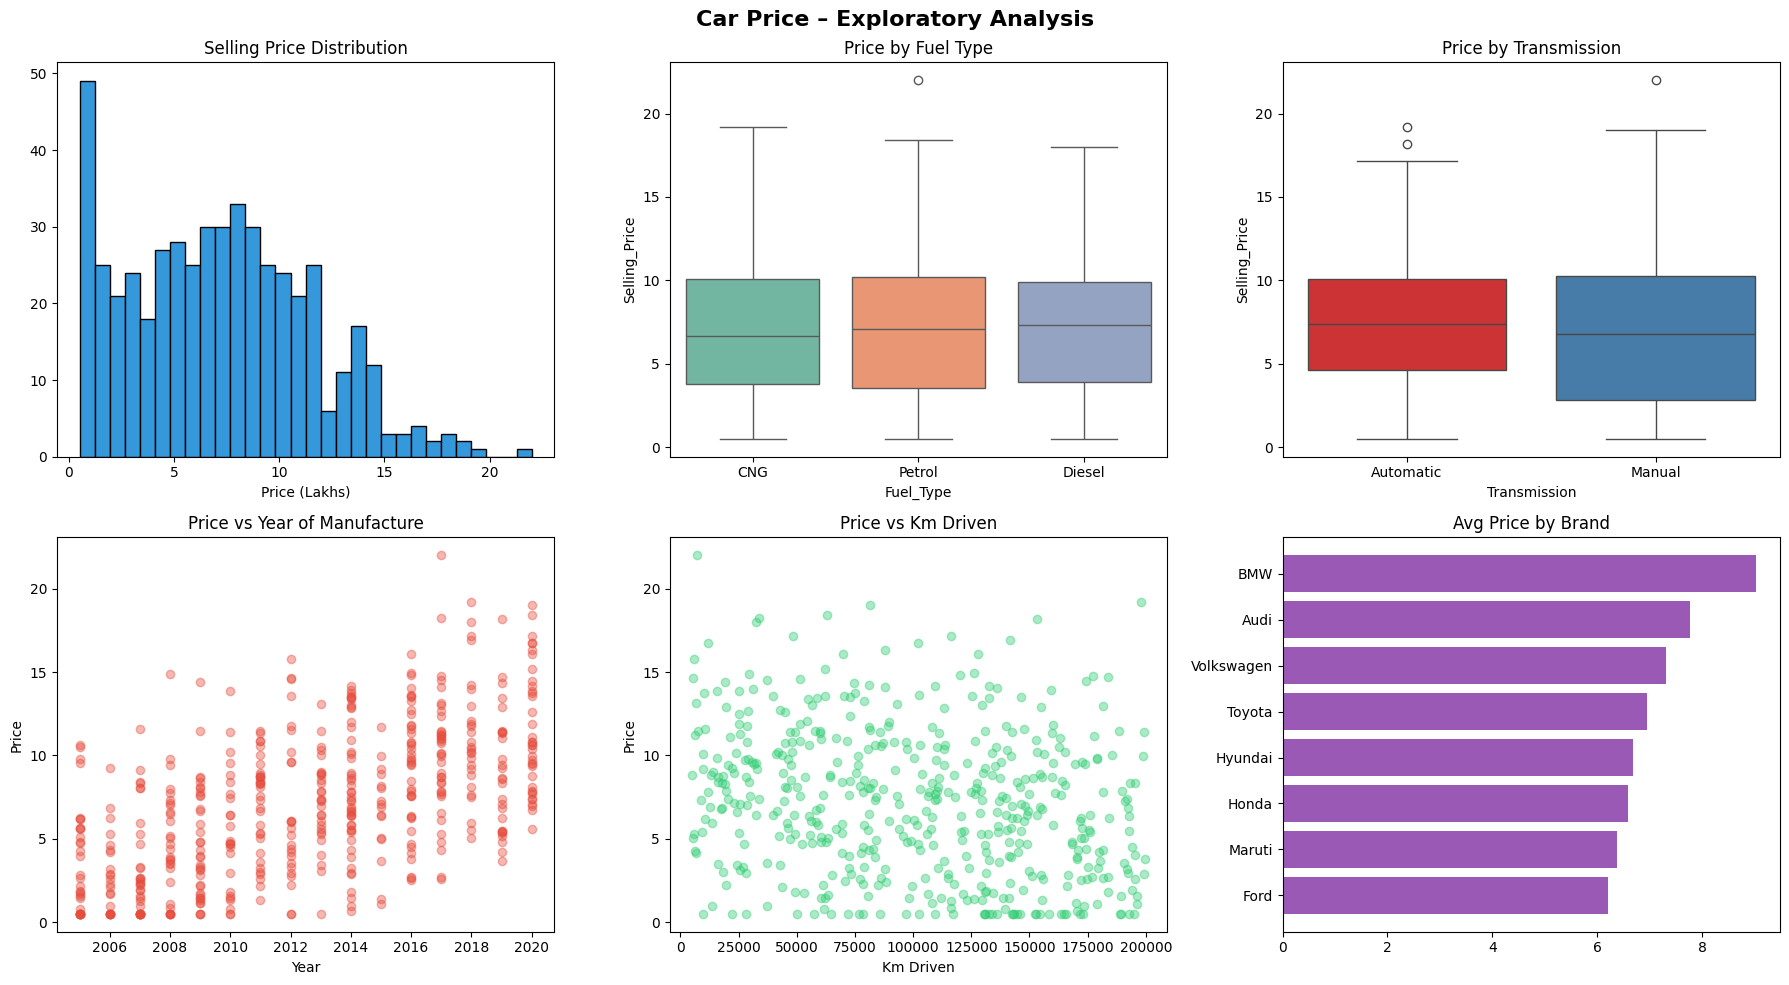

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Car Price – Exploratory Analysis', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(df['Selling_Price'], bins=30, color='#3498db', edgecolor='black')
axes[0,0].set_title('Selling Price Distribution')
axes[0,0].set_xlabel('Price (Lakhs)')

# 2. Price by Fuel Type
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0,1],
            palette='Set2')
axes[0,1].set_title('Price by Fuel Type')

# 3. Price by Transmission
sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[0,2],
            palette='Set1')
axes[0,2].set_title('Price by Transmission')

# 4. Price vs Year
axes[1,0].scatter(df['Year'], df['Selling_Price'], alpha=0.4, color='#e74c3c')
axes[1,0].set_title('Price vs Year of Manufacture')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Price')

# 5. Price vs Km Driven
axes[1,1].scatter(df['Km_Driven'], df['Selling_Price'], alpha=0.4, color='#2ecc71')
axes[1,1].set_title('Price vs Km Driven')
axes[1,1].set_xlabel('Km Driven'); axes[1,1].set_ylabel('Price')

# 6. Avg price by brand
brand_price = df.groupby('Car_Name')['Selling_Price'].mean().sort_values()
axes[1,2].barh(brand_price.index, brand_price.values, color='#9b59b6')
axes[1,2].set_title('Avg Price by Brand')

plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing & Feature Engineering

Correlation with Selling Price:
Selling_Price    1.000000
Max_Power        0.648019
Year             0.589077
Engine           0.569804
Price_Per_KM     0.419015
Seats            0.044144
Fuel_Type        0.014611
Owner           -0.019007
Transmission    -0.035680
Seller_Type     -0.046810
Car_Name        -0.083379
Km_Driven       -0.236047
Car_Age         -0.589077
Name: Selling_Price, dtype: float64


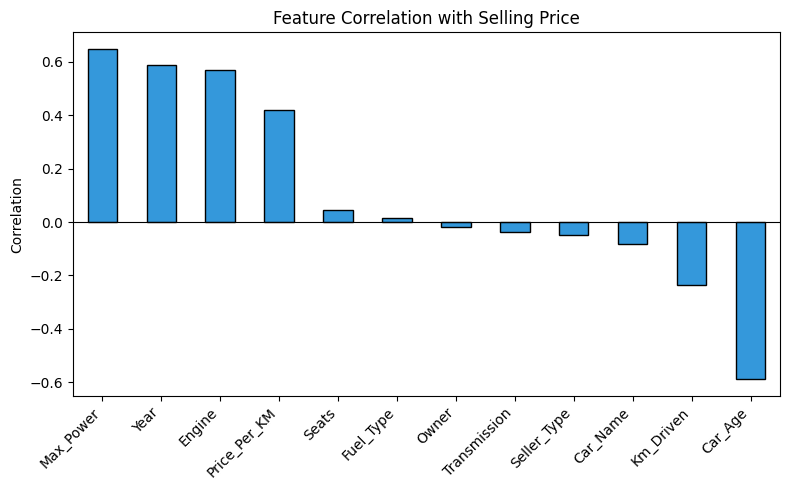


Train: (400, 11), Test: (100, 11)


In [5]:
df_model = df.copy()

# Feature Engineering
df_model['Car_Age'] = 2024 - df_model['Year']
df_model['Price_Per_KM'] = df_model['Selling_Price'] / (df_model['Km_Driven'] + 1)

# Encode categoricals
le = LabelEncoder()
cat_cols = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Drop target leakage columns
X = df_model.drop(columns=['Selling_Price', 'Price_Per_KM'])
y = df_model['Selling_Price']

# Correlation with target
corr_with_price = df_model.corr()['Selling_Price'].sort_values(ascending=False)
print('Correlation with Selling Price:')
print(corr_with_price)

plt.figure(figsize=(8, 5))
corr_with_price.drop('Selling_Price').plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Feature Correlation with Selling Price')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

## Step 5: Train Regression Models

In [6]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

models = {
    'Linear Regression':      LinearRegression(),
    'Ridge Regression':       Ridge(alpha=1.0),
    'Lasso Regression':       Lasso(alpha=0.01),
    'Decision Tree':          DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':          RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':                XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []
trained = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results.append(evaluate(name, y_test, y_pred))
    trained[name] = (model, y_pred)
    print(f'{name:<25} | R²={results[-1]["R2"]:.4f} | MAE={results[-1]["MAE"]:.4f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print('\n=== Model Comparison ===')
print(results_df.to_string(index=False))

Linear Regression         | R²=0.8427 | MAE=1.3297
Ridge Regression          | R²=0.8423 | MAE=1.3300
Lasso Regression          | R²=0.8423 | MAE=1.3258
Decision Tree             | R²=0.7597 | MAE=1.6497
Random Forest             | R²=0.8814 | MAE=1.1556
Gradient Boosting         | R²=0.8998 | MAE=0.9777
XGBoost                   | R²=0.8787 | MAE=1.1478

=== Model Comparison ===
            Model    MAE   RMSE     R2
Gradient Boosting 0.9777 1.3478 0.8998
    Random Forest 1.1556 1.4666 0.8814
          XGBoost 1.1478 1.4832 0.8787
Linear Regression 1.3297 1.6891 0.8427
 Ridge Regression 1.3300 1.6912 0.8423
 Lasso Regression 1.3258 1.6910 0.8423
    Decision Tree 1.6497 2.0875 0.7597


Best Model: Gradient Boosting


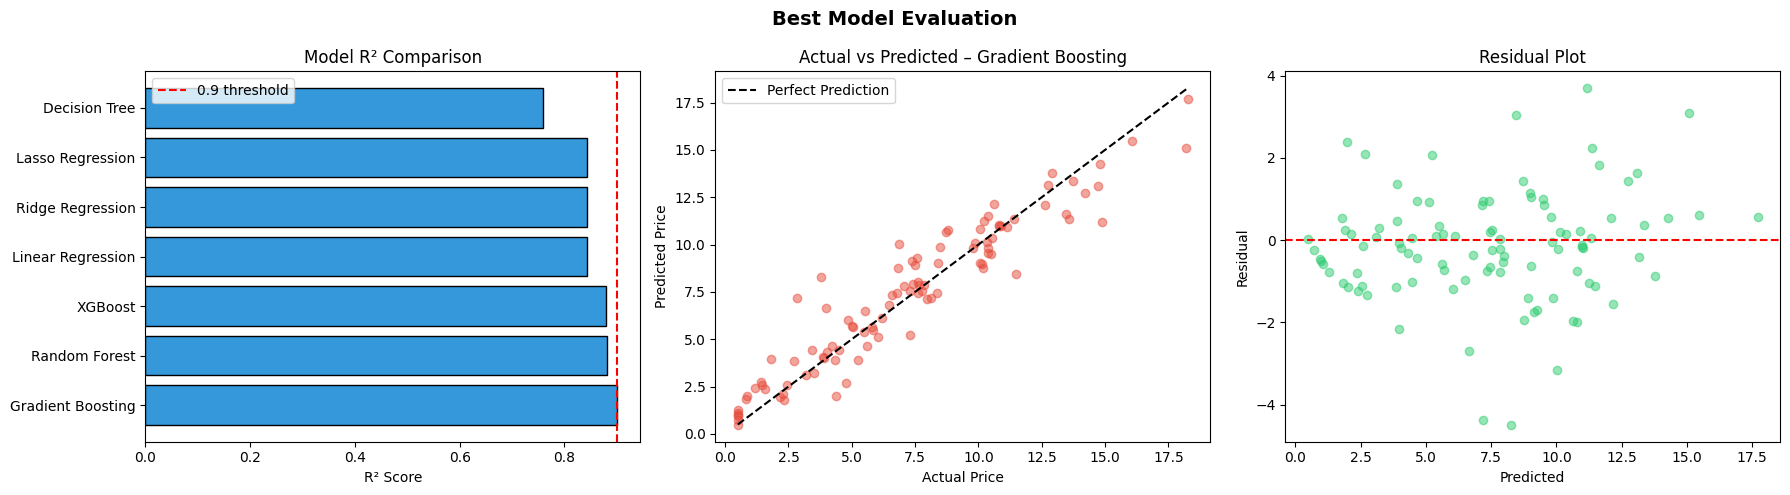

In [7]:
best_name = results_df.iloc[0]['Model']
best_model, best_pred = trained[best_name]
print(f'Best Model: {best_name}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² comparison
axes[0].barh(results_df['Model'], results_df['R2'], color='#3498db', edgecolor='black')
axes[0].set_xlabel('R² Score'); axes[0].set_title('Model R² Comparison')
axes[0].axvline(0.9, color='red', linestyle='--', label='0.9 threshold')
axes[0].legend()

# Actual vs Predicted
axes[1].scatter(y_test, best_pred, alpha=0.5, color='#e74c3c')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'k--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price'); axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Actual vs Predicted – {best_name}')
axes[1].legend()

# Residuals
residuals = y_test - best_pred
axes[2].scatter(best_pred, residuals, alpha=0.5, color='#2ecc71')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Residual')
axes[2].set_title('Residual Plot')

plt.suptitle('Best Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Neural Network with TensorFlow/Keras

In [8]:
tf.random.set_seed(42)
nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32,  activation='relu'),
    Dense(1)
])

nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
           loss='mse', metrics=['mae'])
nn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = nn.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=200, batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 66.5361 - mae: 6.9847 - val_loss: 69.1519 - val_mae: 7.2311
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 52.6639 - mae: 6.2127 - val_loss: 63.8819 - val_mae: 6.9323
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 41.0085 - mae: 5.5066 - val_loss: 57.7851 - val_mae: 6.5777
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30.9091 - mae: 4.6944 - val_loss: 50.8700 - val_mae: 6.1616
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.0800 - mae: 3.9467 - val_loss: 43.5831 - val_mae: 5.6905
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.4404 - mae: 3.2931 - val_loss: 36.5201 - val_mae: 5.1917
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.0472 - mae: 2.7385 - val_loss: 30.5584 - val_mae: 4.7119
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.3731 - mae: 2.3201 - val_loss: 25.6101 - val_mae: 4.2705
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Neural Network → R²: 0.8646 | MAE: 1.2690


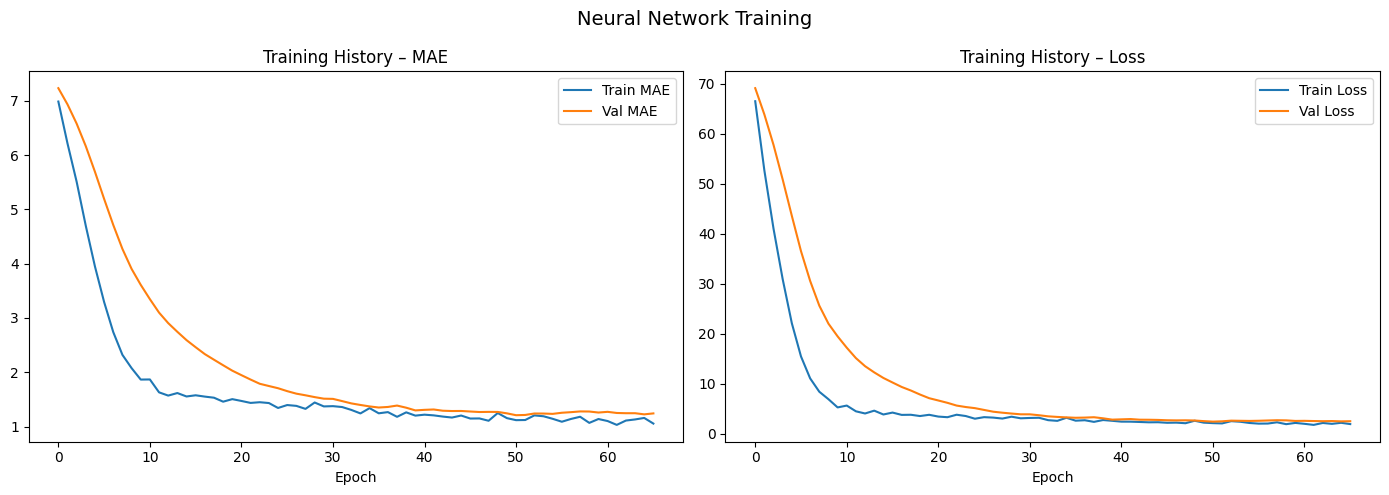


Task 3 Complete!


In [9]:
nn_pred = nn.predict(X_test_s).flatten()
nn_r2   = r2_score(y_test, nn_pred)
nn_mae  = mean_absolute_error(y_test, nn_pred)
print(f'Neural Network → R²: {nn_r2:.4f} | MAE: {nn_mae:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['mae'],     label='Train MAE')
ax1.plot(history.history['val_mae'], label='Val MAE')
ax1.set_title('Training History – MAE')
ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Training History – Loss')
ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('Neural Network Training', fontsize=14)
plt.tight_layout()
plt.show()
print('\nTask 3 Complete!')